## DOWNLOAD & FIX MULTIINDEX DATA (CRITICAL)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

def download_data(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end)

    # --- Extract Close & Volume safely from MultiIndex ---
    close = raw['Close'].stack().reset_index()
    volume = raw['Volume'].stack().reset_index()

    close.columns = ['Date', 'Ticker', 'Close']
    volume.columns = ['Date', 'Ticker', 'Volume']

    df = close.merge(volume, on=['Date', 'Ticker'], how='inner')
    df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    return df

tickers = ['AAPL', 'MSFT', 'KO', 'PEP', 'XOM']
df = download_data(tickers, "2015-01-01", "2024-01-01")

print(df.head())


[*********************100%***********************]  5 of 5 completed

        Date Ticker      Close     Volume
0 2015-01-02   AAPL  24.237556  212818400
1 2015-01-05   AAPL  23.554739  257142000
2 2015-01-06   AAPL  23.556957  263188400
3 2015-01-07   AAPL  23.887280  160423600
4 2015-01-08   AAPL  24.805073  237458000


## TIME-SERIES OPERATORS (WORLDQUANT EQUIVALENTS)

In [2]:
def ts_delta(series, n):
    return series - series.shift(n)

def ts_sum(series, n):
    return series.rolling(n).sum()

def ts_arg_max(series, n):
    # returns how many days ago the max occurred
    return series.rolling(n).apply(
        lambda x: np.argmax(x[::-1]), raw=True
    )

def cross_sectional_rank(df, col):
    return df.groupby('Date')[col].rank(pct=True)


## BUILD THE VOLUME TRIGGER (TRADE GATE)

In [3]:
df['vol_argmax_5'] = df.groupby('Ticker')['Volume'].transform(
    lambda x: ts_arg_max(x, 5)
)

df['vol_avg_5'] = df.groupby('Ticker')['Volume'].transform(
    lambda x: ts_sum(x, 5) / 5
)

df['trigger_trade'] = (
    (df['vol_argmax_5'] < 1) &
    (df['Volume'] >= df['vol_avg_5'])
).astype(int)

print(df[['Date','Ticker','Volume','trigger_trade']].tail())


            Date Ticker    Volume  trigger_trade
11315 2023-12-22    XOM  12927800              0
11316 2023-12-26    XOM  16835100              0
11317 2023-12-27    XOM  14558800              0
11318 2023-12-28    XOM  16329300              0
11319 2023-12-29    XOM  17746400              1


## BUILD THE ALPHA SIGNAL (SHORT-TERM REVERSAL)

In [4]:
df['delta_2'] = df.groupby('Ticker')['Close'].transform(
    lambda x: ts_delta(x, 2)
)

df['alpha_raw'] = -df['delta_2']
df['alpha_ranked'] = cross_sectional_rank(df, 'alpha_raw')


## APPLY trade_when LOGIC + CLEAN NaNs

In [5]:
df['alpha_final'] = np.where(
    df['trigger_trade'] == 1,
    df['alpha_ranked'],
    0
)

df = df.dropna(subset=['alpha_final'])

print(df[['Date','Ticker','alpha_final']].tail())


            Date Ticker  alpha_final
11315 2023-12-22    XOM          0.0
11316 2023-12-26    XOM          0.0
11317 2023-12-27    XOM          0.0
11318 2023-12-28    XOM          0.0
11319 2023-12-29    XOM          1.0


## # Drop rows where core components are missing

In [6]:
# Drop rows where core components are missing
required_cols = [
    'Close', 'Volume',
    'vol_argmax_5', 'vol_avg_5',
    'alpha_ranked', 'alpha_final'
]

df_clean = df.dropna(subset=required_cols).copy()

print("Rows before drop:", len(df))
print("Rows after drop:", len(df_clean))


Rows before drop: 11320
Rows after drop: 11300


## VISUALIZE PRICE + VOLUME (SANITY CHECK)

In [8]:
import matplotlib.pyplot as plt

def visualize_price_volume(
    df,
    ticker,
    start_date=None,
    end_date=None
):
    """
    Sanity-check visualization:
    - Price (line)
    - Volume (bars)
    For ONE ticker only (intentional).
    """

    # ---- Filter ticker ----
    sub = df[df['Ticker'] == ticker].copy()

    # ---- Optional date filtering ----
    if start_date:
        sub = sub[sub['Date'] >= start_date]
    if end_date:
        sub = sub[sub['Date'] <= end_date]

    if sub.empty:
        raise ValueError(f"No data found for ticker {ticker}")

    # ---- Plot ----
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Price
    ax1.plot(
        sub['Date'],
        sub['Close'],
        color='black',
        linewidth=1.8,
        label='Close Price'
    )
    ax1.set_ylabel('Price', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    # Volume (secondary axis)
    ax2 = ax1.twinx()
    ax2.bar(
        sub['Date'],
        sub['Volume'],
        color='steelblue',
        alpha=0.35,
        label='Volume'
    )
    ax2.set_ylabel('Volume', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    # Titles & layout
    plt.title(f"{ticker} — Price & Volume (Sanity Check)")
    fig.tight_layout()

    # Legends (manual merge)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.show()


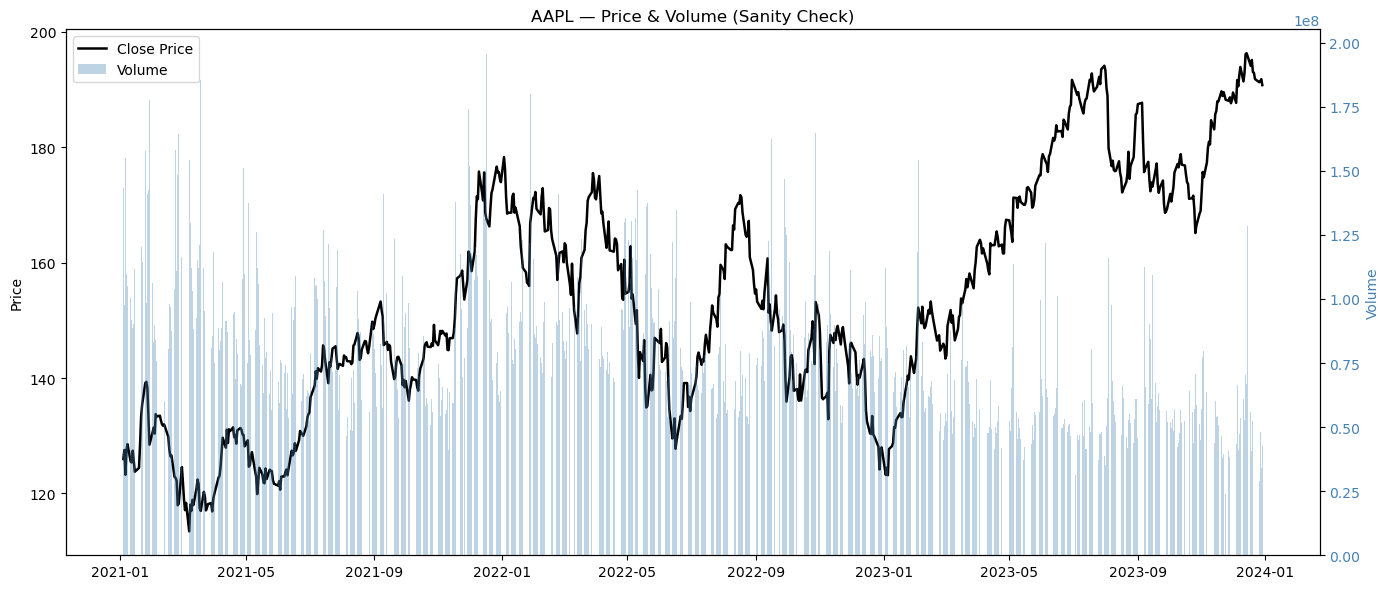

In [9]:
visualize_price_volume(
    df_clean,
    ticker="AAPL",
    start_date="2021-01-01",
    end_date="2023-12-31"
)
